# 02 — Evaluating the score, independently of any decision

**Three questions, three layers, three metrics.** That is the whole structure of this notebook, and
of the module it draws on.

| Question | What is judged | With what |
|---|---|---|
| Does the model rank well? | the **score** | AUC, and AP read against $\pi$ |
| Are its probabilities right? | **calibration** | reliability diagram, Brier score |
| Is the decision good? | the **threshold** | expected cost, at the cost-implied threshold |

**Each layer needs the previous one, and not the other way round.** Good ranking does not guarantee
good probabilities — which is exactly why the AUC cannot see calibration. And good probabilities do
not yield a decision: that takes costs, which are not in the data.

This notebook covers the first two layers. The third is notebook 03 — and it can only be built once
layer two has been checked, since it turns probabilities into dollars.


In [1]:
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_curve, roc_auc_score, precision_recall_curve,
                             average_precision_score, brier_score_loss, auc)

try:
    from google.colab import drive
    drive.mount('/content/drive')
    ROOT = '/content/drive/MyDrive/credit-decision'
    IN_COLAB = True
except ImportError:          # local run, from the notebooks/ folder
    ROOT = '..'
    IN_COLAB = False

ART = f'{ROOT}/artefacts'                                   # regenerable, never versioned
FIG = f'{ROOT}/figures' if IN_COLAB else f'{ROOT}/reports/figures'
os.makedirs(ART, exist_ok=True)
os.makedirs(FIG, exist_ok=True)

scores = pd.read_parquet(f'{ART}/scores_test.parquet')
y_test = scores['y_test'].values
proba_ref = scores['proba_ref'].values
proba_lasso = scores['proba_lasso'].values
pi = y_test.mean()

print(len(y_test), f"pi = {pi:.4f}")

Mounted at /content/drive
75029 pi = 0.2018


## 1. Layer one — ranking: ROC and PR

**The two curves do not tell the same story, by design.**

Both ROC axes are conditioned on the true class, so the curve ignores the proportion of defaults.
That is what makes it comparable across portfolios — and what makes it silent about what the alerts
are worth.

Precision, on the other hand, normalises by the loans the model **flags**. Its baseline is
therefore not 0.5 but $\pi$, and a PR area is never read without quoting that number.


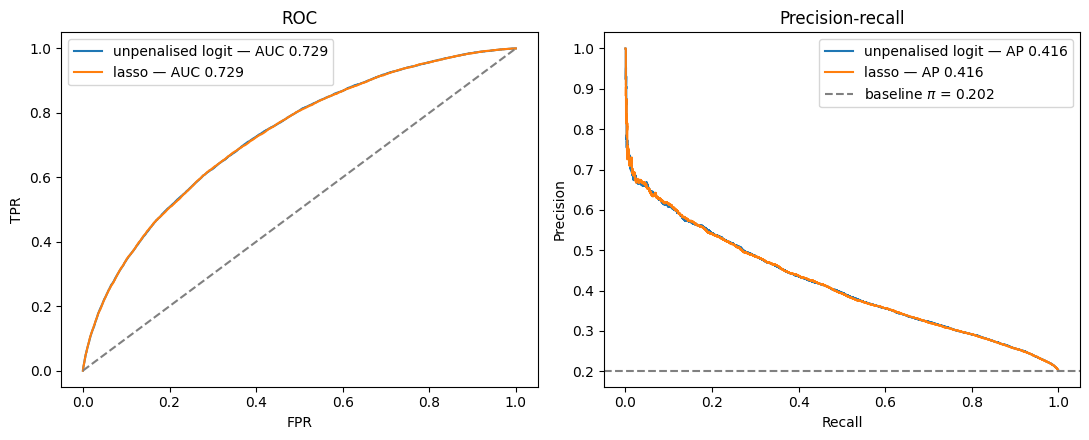

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

for name, p in [('unpenalised logit', proba_ref), ('lasso', proba_lasso)]:
    fpr, tpr, _ = roc_curve(y_test, p)
    ax[0].plot(fpr, tpr, label=f"{name} — AUC {roc_auc_score(y_test, p):.3f}")
    prec, rec, _ = precision_recall_curve(y_test, p)
    ax[1].plot(rec, prec, label=f"{name} — AP {average_precision_score(y_test, p):.3f}")

ax[0].plot([0, 1], [0, 1], '--', color='grey')
ax[0].set_xlabel('FPR'); ax[0].set_ylabel('TPR'); ax[0].set_title('ROC'); ax[0].legend()
ax[1].axhline(pi, ls='--', color='grey', label=f"baseline $\\pi$ = {pi:.3f}")
ax[1].set_xlabel('Recall'); ax[1].set_ylabel('Precision')
ax[1].set_title('Precision-recall'); ax[1].legend()
plt.tight_layout()
fig.savefig(f'{FIG}/roc_pr.png', dpi=150, bbox_inches='tight'); plt.show()

In [3]:
# The PR area is a sum of rectangles, never trapezoids: the curve is not monotone,
# and linear interpolation cuts corners, overstating the area.
prec, rec, _ = precision_recall_curve(y_test, proba_lasso)
print("average_precision:", average_precision_score(y_test, proba_lasso))
print("auc(rec, prec)   :", auc(rec, prec), "  <- overstated")

average_precision: 0.4156688701968748
auc(rec, prec)   : 0.4156223228496672   <- overstated


## 2. Layer two — is the score calibrated?

**What "calibrated" means, literally.** Take every loan the model scored 0.30; among them, 30 %
should default. Then those scored 0.70: 70 % should default. And so on for every value.

Note what is being conditioned on: **the score, not the class**. Calibration does not say "the
model is right 70 % of the time", nor "it catches 70 % of defaults" — that is recall. It says that
*within the group scored $u$*, the observed frequency equals $u$. It is a property of groups, never
of individuals: nobody is "30 % in default", they either default or they don't.

**Why a good AUC is not enough.** Take a perfectly calibrated model and divide every score by ten.
The loans are ranked exactly as before, so the ROC, the AUC and the AP are unchanged — yet a
borrower at 30 % risk now reads 0.03, and a cost threshold would flag nobody at all. The AUC
measures *order*; a cost threshold needs *level*.

**The reliability diagram** bins loans by score — **by quantiles**, not equal-width bins, since the
scores are bunched near the bottom and the upper bins would be empty — and plots observed default
frequency against mean predicted score. A calibrated model follows the diagonal. Points below it
mean the model overstates risk, above it that it understates; a flat cloud around $\pi$ means a
model too timid to move away from the base rate.


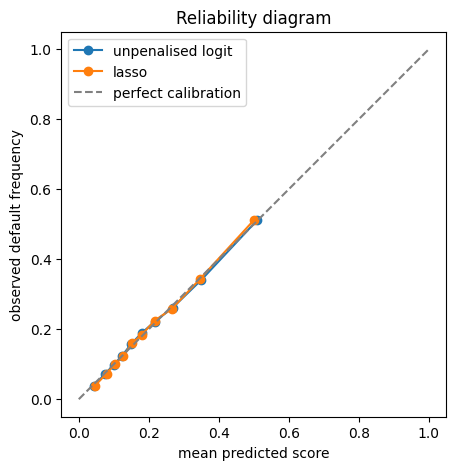

,mean_score,observed_freq,count
q,,,
0,0.0460,0.0385,7503
1,0.0796,0.0734,7503
2,0.1039,0.1006,7503
3,0.1273,0.1228,7503
4,0.1520,0.1602,7503
5,0.1807,0.1849,7502
6,0.2166,0.2244,7503
7,0.2666,0.2590,7503
8,0.3455,0.3427,7503


In [4]:
def reliability(y, p, n_bins=10):
    q = pd.qcut(p, n_bins, labels=False, duplicates='drop')
    return (pd.DataFrame({'p': p, 'y': y, 'q': q})
              .groupby('q').agg(mean_score=('p', 'mean'),
                                observed_freq=('y', 'mean'),
                                count=('y', 'size')))

fig, ax = plt.subplots(figsize=(5, 5))
for name, p in [('unpenalised logit', proba_ref), ('lasso', proba_lasso)]:
    t = reliability(y_test, p)
    ax.plot(t['mean_score'], t['observed_freq'], marker='o', label=name)
ax.plot([0, 1], [0, 1], '--', color='grey', label='perfect calibration')
ax.set_xlabel('mean predicted score'); ax.set_ylabel('observed default frequency')
ax.set_title('Reliability diagram'); ax.legend(); ax.set_aspect('equal')
fig.savefig(f'{FIG}/reliability.png', dpi=150, bbox_inches='tight'); plt.show()

reliability(y_test, proba_lasso).round(4)

**The Brier score** is the mean squared gap between the probability announced and the outcome
observed. It decomposes (Murphy) into

$$\text{Brier} = \underbrace{\text{calibration}}_{\text{to minimise}} - \underbrace{\text{resolution}}_{\text{discriminating power}} + \underbrace{\text{uncertainty}}_{\pi(1-\pi)}$$

and it is the decomposition that should be quoted, never the bare number: it names **which** of the
two qualities is at fault. Under the divide-by-ten transformation, resolution is untouched — the
ordering did not move — and only the calibration term blows up.

The benchmark: a model announcing $\pi$ to everyone scores $\pi(1-\pi)$, here about 0.161. That
is the number to beat, and a Brier score is never read without it.

Computed here on the same ten quantile bins as the diagram. The identity is then only
approximate — binning ignores the spread of scores inside each bin — so the reconstructed total
sits close to, but not exactly on, the true Brier.

The last row checks the divide-by-ten claim numerically. Quantile bins are invariant under any
increasing transformation, so the bins, and hence the resolution, are **exactly** unchanged; only
the calibration term moves.


In [5]:
def murphy(y, p, n_bins=10):
    t = reliability(y, p, n_bins)
    w = t['count'] / t['count'].sum()
    ybar = y.mean()
    return {'Brier': brier_score_loss(y, p),
            'calibration': (w * (t['mean_score'] - t['observed_freq'])**2).sum(),
            'resolution': (w * (t['observed_freq'] - ybar)**2).sum(),
            'uncertainty': ybar * (1 - ybar)}

tab = pd.DataFrame({name: murphy(y_test, p) for name, p in
                    [('unpenalised logit', proba_ref), ('lasso', proba_lasso),
                     ('lasso / 10', proba_lasso / 10)]}).T
tab.loc['pi only'] = [pi * (1 - pi), 0.0, 0.0, pi * (1 - pi)]
tab['cal - res + unc'] = tab['calibration'] - tab['resolution'] + tab['uncertainty']
tab.round(4)


,Brier,calibration,resolution,uncertainty,cal - res + unc
unpenalised logit,0.1421,0.0000,0.0181,0.1611,0.1430
lasso,0.1422,0.0000,0.0181,0.1611,0.1430
lasso / 10,0.1906,0.0478,0.0181,0.1611,0.1907
pi only,0.1611,0.0000,0.0000,0.1611,0.1611


## 3. Unpenalised logit versus lasso

What sparsity costs, quantified on the test set. The lasso keeps a fraction of the columns; if the
performance loss is small, simplicity comes for free — and it is a requirement rather than a
preference, since a credit refusal must be explainable. How far that simplicity can be pushed
(regularisation path, stability of the selection) is studied in notebook 01, §10–11, where the
training data lives.


In [6]:
pd.DataFrame({
    'AUC': [roc_auc_score(y_test, proba_ref), roc_auc_score(y_test, proba_lasso)],
    'AP': [average_precision_score(y_test, proba_ref),
           average_precision_score(y_test, proba_lasso)],
    'Brier': [brier_score_loss(y_test, proba_ref), brier_score_loss(y_test, proba_lasso)],
}, index=['unpenalised logit', 'lasso']).round(4)

,AUC,AP,Brier
unpenalised logit,0.7294,0.4156,0.1421
lasso,0.7291,0.4157,0.1422


## Takeaways for the README

- An AP is read against $\pi$, never in the absolute: 0.416 against 0.202.
- A Brier score is read against $\pi(1-\pi) = 0.161$, and through its decomposition: it says whether
  the fault is ranking (resolution) or level (calibration).
- Both models are calibrated (calibration term below $5\times10^{-5}$) and have the same
  resolution (0.0181): the lasso loses nothing. No recalibration is needed before notebook 03.
- The Brier skill score is 11.8 %: modest, and normal in credit — most causes of default (a job
  loss, an illness) are not in the application file.
- Dividing every score by ten leaves the ranking — and the AUC — untouched, yet makes the Brier score
  worse than predicting $\pi$ for everyone. That is why this notebook exists.